Final Cluster Centers (Weights):
[[-1.85591724 -2.06980479]
 [ 1.95528646  2.01902428]
 [ 2.38951576 -2.14004767]]


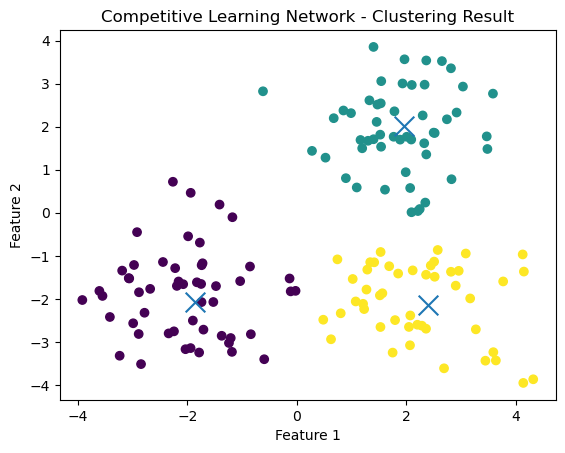

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Competitive:
    def __init__(self, neurons=3, lr=0.1, epochs=60):
        self.neurons = neurons
        self.lr = lr
        self.epochs = epochs

    def fit(self, X):
        self.weights = np.random.rand(self.neurons, X.shape[1])

        for _ in range(self.epochs):
            for x in X:
                d = np.linalg.norm(self.weights - x, axis=1)
                idx = np.argmin(d)
                self.weights[idx] += self.lr * (x - self.weights[idx])

    def predict(self, X):
        labels = []
        for x in X:
            d = np.linalg.norm(self.weights - x, axis=1)
            labels.append(np.argmin(d))
        return np.array(labels)


np.random.seed(2)
A = np.random.randn(50,2) + [2,1]
B = np.random.randn(50,2) + [-2,-1]
C = np.random.randn(50,2) + [1,-2]

X = np.vstack((A,B,C))

model = Competitive()
model.fit(X)

labels = model.predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(model.weights[:,0], model.weights[:,1], marker='x', s=150)
plt.show()